# Notebook 07: Follow-Up Prediction

Binary classification: does this patient need a follow-up visit?

Labels come from LLM entity extraction (mts_entities.json): 1,199 usable samples, 35% positive.

In [10]:
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import joblib

train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

with open('../data/processed/mts_entities.json') as f:
    entities = json.load(f)

#merge follow-up labels into training data
train_df['follow_up'] = train_df['ID'].astype(str).map(
    lambda x: entities.get(x, {}).get('follow_up_needed')
)
train_df = train_df.dropna(subset=['follow_up'])
train_df['follow_up'] = train_df['follow_up'].astype(int)

print(f"Samples: {len(train_df)}")
print(f"\nFollow-up distribution:")
print(train_df['follow_up'].value_counts())

Samples: 1199

Follow-up distribution:
follow_up
0    781
1    418
Name: count, dtype: int64


## Feature Engineering

Same pipeline as section classification: TF-IDF (500 features), dialogue features, and entity features.

In [11]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(train_df['dialogue'])

# Dialogue features
def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

# Entity features
def extract_entity_features(df, entities):
    features = pd.DataFrame(index=df.index)
    for _, row in df.iterrows():
        ent = entities.get(str(row['ID']), {})
        features.loc[row.name, 'num_symptoms'] = len(ent.get('symptoms', []))
        features.loc[row.name, 'num_diagnoses'] = len(ent.get('diagnoses', []))
        features.loc[row.name, 'num_medications'] = len(ent.get('medications', []))
        features.loc[row.name, 'has_chief_complaint'] = int(bool(ent.get('chief_complaint', '')))
        sev = str(ent.get('severity', '')).strip().lower()
        features.loc[row.name, 'severity_high'] = int(sev == 'high')
        features.loc[row.name, 'severity_low'] = int(sev == 'low')
    return features.astype(float)

X_dialogue = extract_dialogue_features(train_df)
X_entity = extract_entity_features(train_df, entities)
X_combined = hstack([X_tfidf, X_dialogue.values, X_entity.values])

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_combined)
y = train_df['follow_up'].values

print(f"Feature matrix: {X_scaled.shape}")
print(f"  TF-IDF: 500, Dialogue: {X_dialogue.shape[1]}, Entity: {X_entity.shape[1]}")

Feature matrix: (1199, 511)
  TF-IDF: 500, Dialogue: 5, Entity: 6


## Model Comparison (5-fold CV)

In [12]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
}

cv_results = {}
print("5-Fold Cross-Validation (F1)\n")
for name, model in models.items():
    if name == 'Naive Bayes':
        scores = cross_val_score(model, X_tfidf, y, cv=5, scoring='f1')
    else:
        scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

5-Fold Cross-Validation (F1)

Naive Bayes                F1 = 0.595 (+/- 0.038)
Logistic Regression        F1 = 0.729 (+/- 0.026)
SVM (Linear)               F1 = 0.670 (+/- 0.022)
SVM (RBF)                  F1 = 0.750 (+/- 0.017)
Random Forest              F1 = 0.711 (+/- 0.027)
XGBoost                    F1 = 0.742 (+/- 0.011)


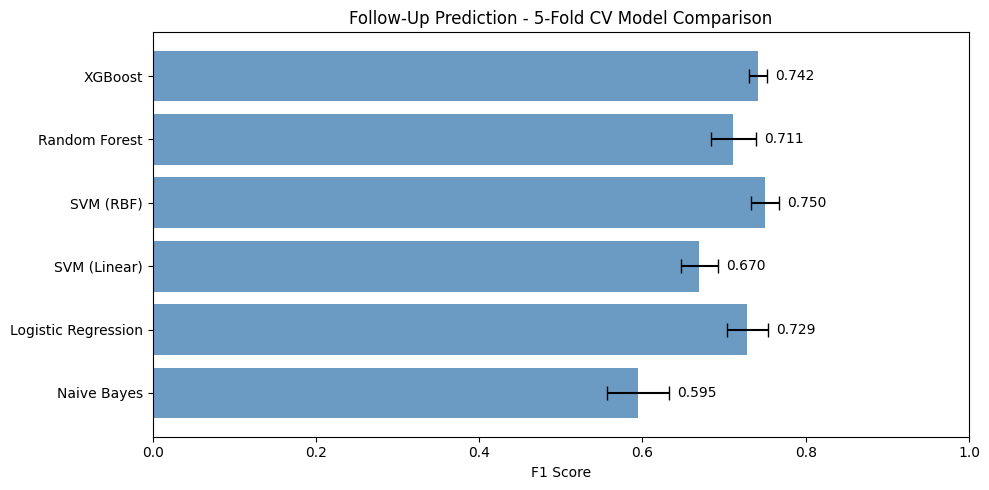

In [13]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]
bars = ax.barh(names, means, xerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_xlabel('F1 Score')
ax.set_title('Follow-Up Prediction - 5-Fold CV Model Comparison')
ax.set_xlim(0, 1.0)
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2, f'{mean:.3f}', va='center')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (top 3 models)

In [14]:
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000),
        'params': {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']},
    },
    'SVM (Linear)': {
        'model': SVC(kernel='linear', class_weight='balanced', random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10, 100]},
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 20, None]},
    },
}

tuned = {}
for name, config in param_grids.items():
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_scaled, y)
    tuned[name] = grid
    print(f"{name}:")
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best F1: {grid.best_score_:.3f}\n")

Logistic Regression:
  Best params: {'C': 0.1, 'solver': 'liblinear'}
  Best F1: 0.747

SVM (Linear):
  Best params: {'C': 0.1}
  Best F1: 0.741

Random Forest:
  Best params: {'max_depth': 10, 'n_estimators': 300}
  Best F1: 0.738



## Best Model: Full Training and Save

In [15]:
# Pick the best tuned model and retrain on full data
best_name = max(tuned, key=lambda k: tuned[k].best_score_)
best_model = tuned[best_name].best_estimator_
print(f"Best model: {best_name}")
print(f"Best CV F1: {tuned[best_name].best_score_:.3f}")
print(f"Params: {tuned[best_name].best_params_}")

# Already fitted on full training set by GridSearchCV (refit=True by default)
# Save
joblib.dump({
    'model': best_model,
    'tfidf': tfidf,
    'scaler': scaler,
}, '../models/followup_classifier.joblib')
print(f"\nSaved to models/followup_classifier.joblib")

Best model: Logistic Regression
Best CV F1: 0.747
Params: {'C': 0.1, 'solver': 'liblinear'}

Saved to models/followup_classifier.joblib


## Confusion Matrix and Classification Report

              precision    recall  f1-score   support

No Follow-Up       0.89      0.80      0.84       781
   Follow-Up       0.69      0.82      0.75       418

    accuracy                           0.81      1199
   macro avg       0.79      0.81      0.80      1199
weighted avg       0.82      0.81      0.81      1199



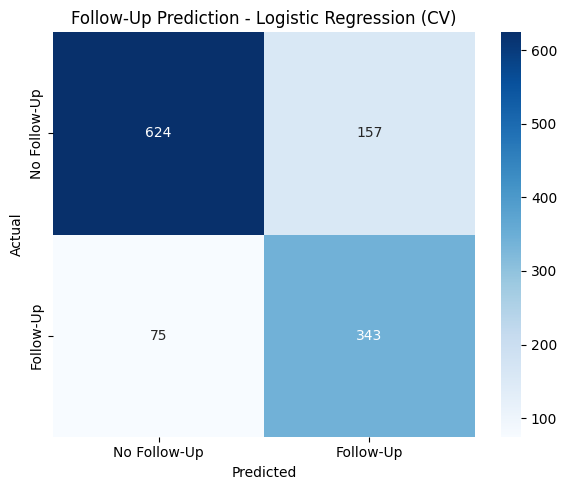

In [16]:
# Cross-validated predictions for confusion matrix
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(best_model, X_scaled, y, cv=5)

print(classification_report(y, y_pred_cv, target_names=['No Follow-Up', 'Follow-Up']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Follow-Up', 'Follow-Up'],
            yticklabels=['No Follow-Up', 'Follow-Up'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Follow-Up Prediction - {best_name} (CV)')
plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves

ROC plots true positive rate against false positive rate at different thresholds.
PR is often more informative when classes are imbalanced.

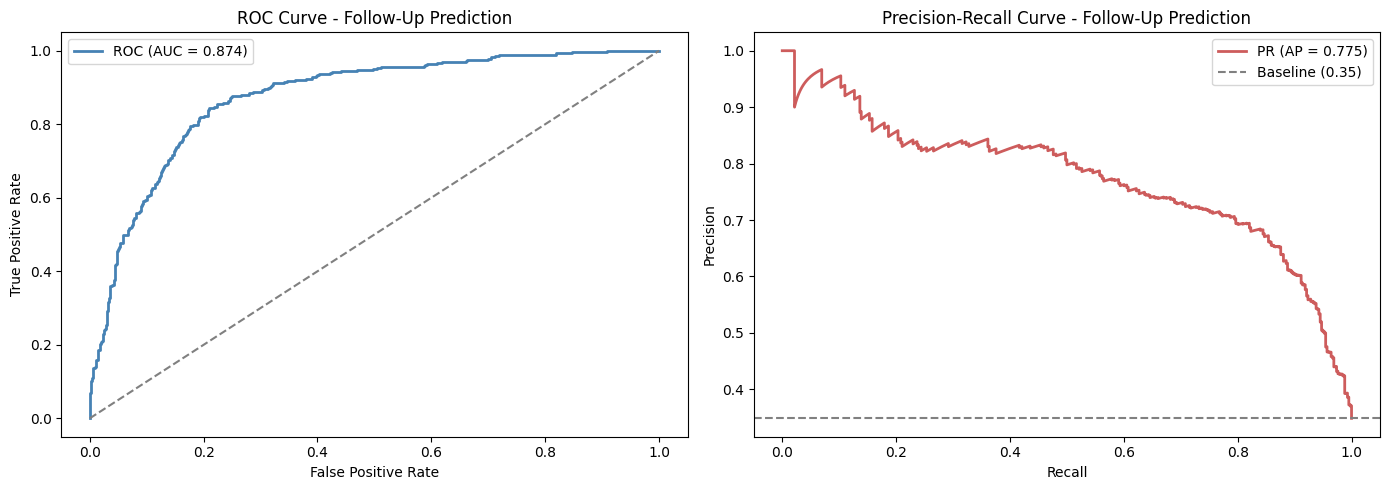

ROC AUC: 0.874
Average Precision: 0.775


In [17]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(best_model, X_scaled, y, cv=5, method='decision_function')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Follow-Up Prediction')
axes[0].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y, y_scores)
ap = average_precision_score(y, y_scores)
axes[1].plot(recall, precision, color='indianred', lw=2, label=f'PR (AP = {ap:.3f})')
baseline_prevalence = y.mean()
axes[1].axhline(y=baseline_prevalence, linestyle='--', color='gray', label=f'Baseline ({baseline_prevalence:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Follow-Up Prediction')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")
print(f"Average Precision: {ap:.3f}")

## Calibration Plot

Does the model's predicted probability match the actual rate of follow-up?
A well-calibrated model should fall along the diagonal.

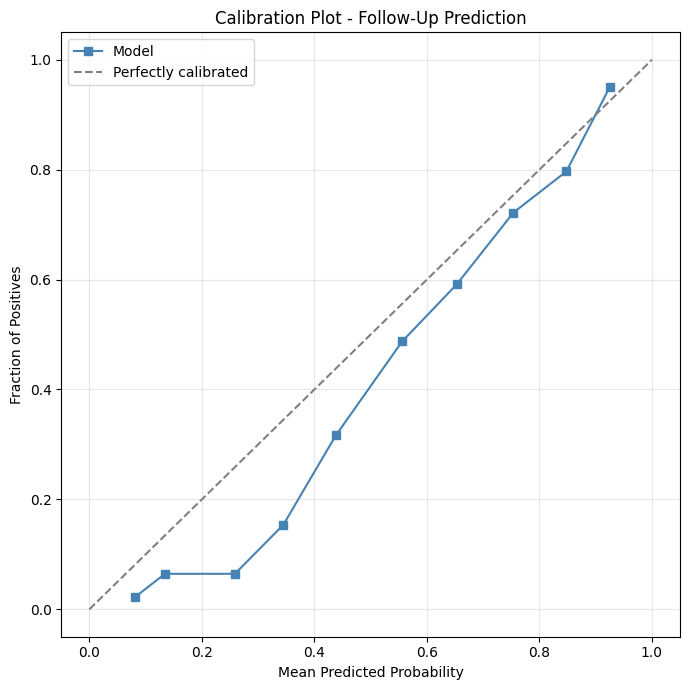

In [18]:
from sklearn.calibration import calibration_curve
from scipy.special import expit

# Convert decision function to probabilities via sigmoid
y_prob = expit(y_scores)

prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred, prob_true, 's-', color='steelblue', label='Model')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Plot - Follow-Up Prediction')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()